In [1]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category=warn)

# Импорт необходимых библиотек
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import polars as pl
import pandas as pd
import sklearn
import networkx as nx
import ipywidgets
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D

import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

from torch import Tensor
from einops import rearrange
from typing import Tuple, Callable
from torch.autograd import Function

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


## Домашнее задание: Обучение и визуализация Mamba

### Цель задания

1. Обучить простую модель Mamba для обработки любых данных (на выбор: текст, аудио, видео, изображения и ...)
2. Визуализировать веса внимания и интерпретировать их
3. Сделать выводы о том, как модель воспринимает данные и принимает решения

Устройство: cuda


100%|██████████| 170M/170M [00:03<00:00, 42.8MB/s]


Параметров: 4,464,970

Начало обучения...

Эпоха [ 1/30] | Loss = 1.8516 | Train = 29.93% | Test = 34.36%
Эпоха [ 5/30] | Loss = 1.2905 | Train = 53.60% | Test = 55.12%
Эпоха [10/30] | Loss = 1.0481 | Train = 62.88% | Test = 64.50%
Эпоха [15/30] | Loss = 0.9131 | Train = 67.79% | Test = 68.49%
Эпоха [20/30] | Loss = 0.8163 | Train = 71.40% | Test = 72.26%
Эпоха [25/30] | Loss = 0.7439 | Train = 73.90% | Test = 74.28%
Эпоха [30/30] | Loss = 0.7151 | Train = 74.92% | Test = 74.88%


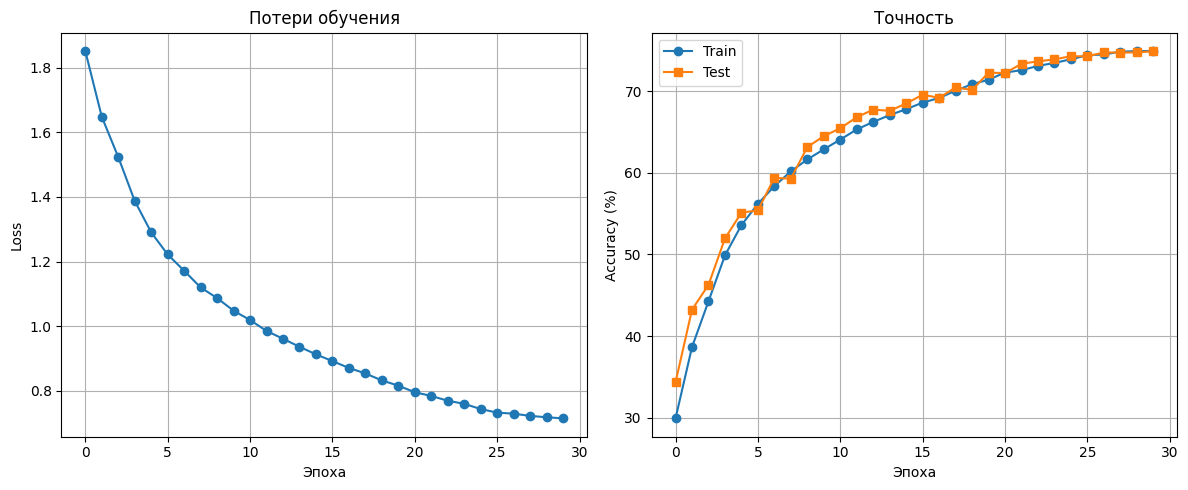

In [2]:
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

def images_to_patches(x, patch_size=4):
    b, c, h, w = x.shape

    x = x.unfold(2, patch_size, patch_size)
    x = x.unfold(3, patch_size, patch_size)

    x = x.permute(0, 2, 3, 1, 4, 5).contiguous()

    x = x.view(
        b,
        (h // patch_size) * (w // patch_size),
        c * patch_size * patch_size
    )

    return x

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

class SimpleSSM(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        self.A = nn.Parameter(
            torch.randn(d_model) * 0.01
        )

        self.B = nn.Linear(d_model, d_model)
        self.C = nn.Linear(d_model, d_model)
        self.D = nn.Linear(d_model, d_model)

    def forward(self, x):

        B, L, D = x.shape

        h = torch.zeros(
            B,
            D,
            device=x.device
        )

        outputs = []

        A = torch.tanh(self.A)

        for t in range(L):

            xt = x[:, t]

            h = A * h + self.B(xt)

            yt = self.C(h) + self.D(xt)

            outputs.append(yt)

        return torch.stack(outputs, dim=1)

class MiniMambaBlock(nn.Module):
    def __init__(self, d_model, expand=2):
        super().__init__()

        hidden_dim = d_model * expand

        self.norm = nn.LayerNorm(d_model)

        self.in_proj = nn.Linear(
            d_model,
            hidden_dim
        )

        self.ssm = SimpleSSM(hidden_dim)

        self.gate = nn.Linear(
            hidden_dim,
            hidden_dim
        )

        self.out_proj = nn.Linear(
            hidden_dim,
            d_model
        )

    def forward(self, x):

        residual = x

        x = self.norm(x)

        x = self.in_proj(x)

        gate = torch.sigmoid(
            self.gate(x)
        )

        x = self.ssm(x)

        x = x * gate

        x = self.out_proj(x)

        return x + residual

class MiniVisionMamba(nn.Module):
    def __init__(
        self,
        input_dim=48,
        num_classes=10,
        d_model=192,
        depth=6,
        seq_len=64
    ):
        super().__init__()

        self.patch_embed = nn.Linear(
            input_dim,
            d_model
        )

        self.pos_embed = nn.Parameter(
            torch.randn(
                1,
                seq_len,
                d_model
            ) * 0.02
        )

        self.blocks = nn.ModuleList([
            MiniMambaBlock(d_model)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(d_model)

        self.head = nn.Linear(
            d_model,
            num_classes
        )

    def forward(self, x):

        x = self.patch_embed(x)

        x = x + self.pos_embed

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)

        x = x.mean(dim=1)

        return self.head(x)

model = MiniVisionMamba(
    input_dim=48,
    num_classes=10,
    d_model=192,
    depth=6
).to(device)

print(
    "Параметров:",
    f"{sum(p.numel() for p in model.parameters()):,}"
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

epochs = 30

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)

train_losses = []
train_accs = []
test_accs = []

print("\nНачало обучения...\n")

for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        x_seq = images_to_patches(
            images,
            patch_size=4
        )

        optimizer.zero_grad()

        outputs = model(x_seq)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (
            preds == labels
        ).sum().item()

    scheduler.step()

    train_loss = (
        total_loss / len(train_loader)
    )

    train_acc = (
        100 * correct / total
    )

    train_losses.append(train_loss)
    train_accs.append(train_acc)


    model.eval()

    correct_test = 0
    total_test = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            x_seq = images_to_patches(
                images,
                patch_size=4
            )

            outputs = model(x_seq)

            preds = outputs.argmax(dim=1)

            total_test += labels.size(0)

            correct_test += (
                preds == labels
            ).sum().item()

    test_acc = (
        100 * correct_test / total_test
    )

    test_accs.append(test_acc)

    if epoch == 0 or (epoch + 1) % 5 == 0:

        print(
            f"Эпоха [{epoch+1:2d}/{epochs}] "
            f"| Loss = {train_loss:.4f} "
            f"| Train = {train_acc:.2f}% "
            f"| Test = {test_acc:.2f}%"
        )

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o')
plt.title("Потери обучения")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train", marker='o')
plt.plot(test_accs, label="Test", marker='s')
plt.title("Точность")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Предположительно, Loss на train может быть ниже, чем Loss на test из-за аугментаций (задача на train фактически сложнее).

Результаты не самые лучшие, но и реализация, опять же, неидеальна. Обучение длилось больше часа на Т4. Простая свёрточная нейросеть выбивала почти 77% за пару минут, а у Visual Mamba 75% похожи на плато. Итого: для задачи классификации маленьких (32 x 32) изображений лучше использовать свёрточные нейросети, либо сильно более продвинутые архитектуры SSM.

Но результат неплохой, оследовательная обработка патчей через SSM способна извлекать значимые визуальные признаки даже без механизма внимания.

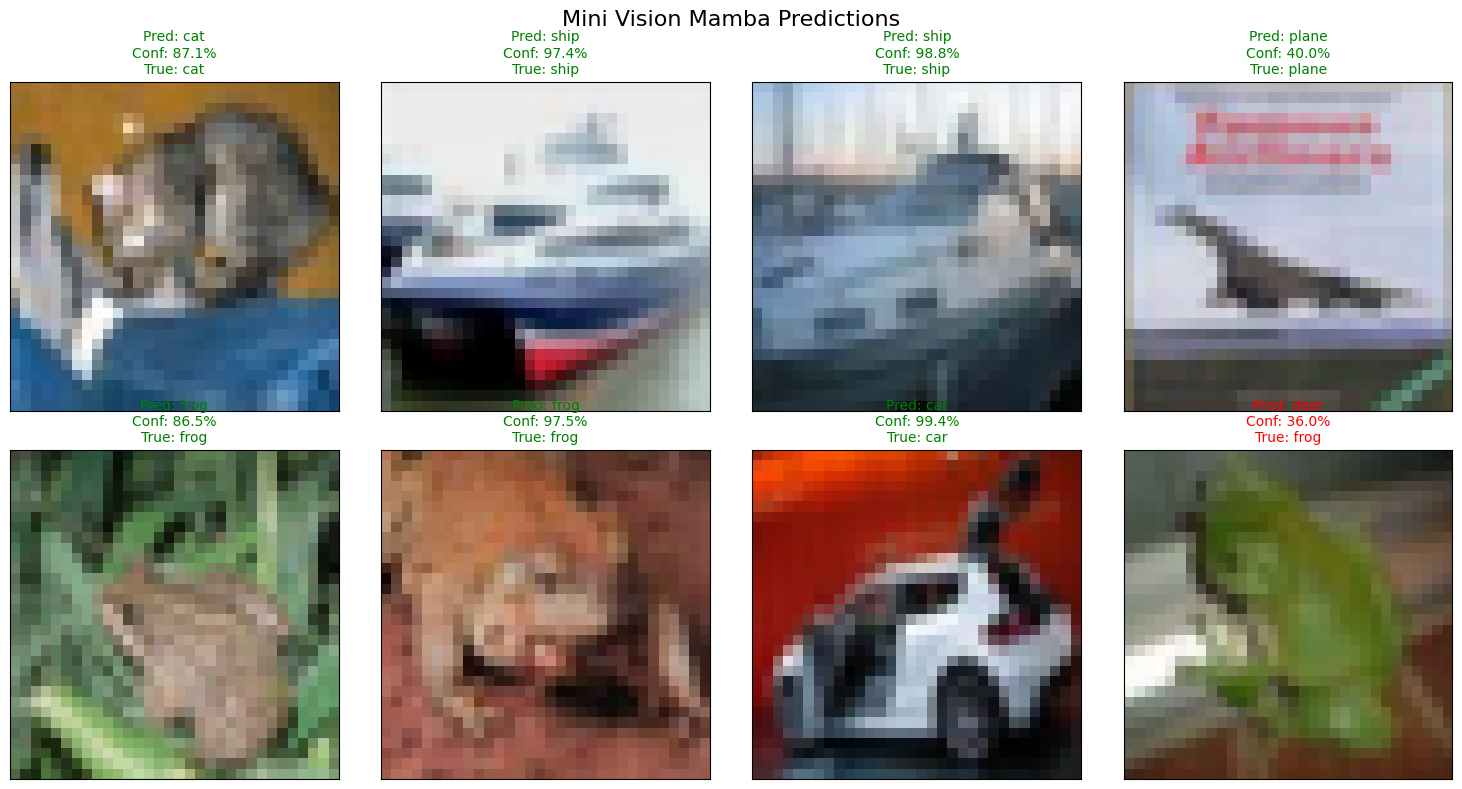

In [4]:
def visualize_predictions(
    model,
    dataloader,
    class_names,
    num_images=8
):
    model.eval()

    images, labels = next(iter(dataloader))

    images = images[:num_images].to(device)
    labels = labels[:num_images].to(device)

    x_seq = images_to_patches(
        images,
        patch_size=4
    )

    with torch.no_grad():

        outputs = model(x_seq)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        confidences, preds = probs.max(dim=1)

    fig = plt.figure(figsize=(15, 8))

    for idx in range(num_images):

        ax = fig.add_subplot(
            2,
            4,
            idx + 1,
            xticks=[],
            yticks=[]
        )

        img = images[idx].cpu()

        img = img.permute(1, 2, 0).numpy()

        img = img * 0.5 + 0.5
        img = np.clip(img, 0, 1)

        ax.imshow(img)

        pred = preds[idx].item()
        true = labels[idx].item()

        conf = confidences[idx].item() * 100

        correct = pred == true

        color = "green" if correct else "red"

        ax.set_title(
            f"Pred: {class_names[pred]}\n"
            f"Conf: {conf:.1f}%\n"
            f"True: {class_names[true]}",
            color=color,
            fontsize=10
        )

    plt.suptitle(
        "Mini Vision Mamba Predictions",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()



class_names = [
    'plane',
    'car',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]


visualize_predictions(
    model,
    test_loader,
    class_names,
    num_images=8
)

На многих изображениях тестовой выборки модель делает предсказание с высокой уверенностью, что указывает на её неплохое качество.